In [ ]:
import platform
from print_versions import get_versions
ver = get_versions(globals())
ver["python"]=platform.python_version()
for k, v in ver.items():
    print(f"{k}: {v}")

qiskit: 1.1.1
numpy: 1.26.4
scipy: 1.10.1
pandas: 3.0.3
fssa: 0.7.6
matplotlib: 3.9.0
platform: 1.0.8
python: 3.11.9


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import pandas as pd
from majorana_xyz import *


H=XYZ_Hamiltonian(3,3,'periodic')
print("Hamiltonian, spectrum, degeneracy")
eigenvalues, eigenvectors = eigh(H.H_down().to_matrix())
eigenvalues=np.round(eigenvalues,decimals=6)
u, c = np.unique(eigenvalues, return_counts=True)
print("H1   "," ".join(f"[{e: .6g},{d:d}]" for e, d in zip(u, c)))

eigenvalues, eigenvectors = eigh(H.H_up().to_matrix())
eigenvalues=np.round(eigenvalues,decimals=6)
u, c = np.unique(eigenvalues, return_counts=True)
print("H2   "," ".join(f"[{e: .6g},{d:d}]" for e, d in zip(u, c)))

eigenvalues, eigenvectors = eigh(H.H_up().to_matrix()+H.H_down().to_matrix())
eigenvalues=np.round(eigenvalues,decimals=6)
u, c = np.unique(eigenvalues, return_counts=True)
print("H1+H2"," ".join(f"[{e: .6g},{d:d}]" for e, d in zip(u, c)))

Hamiltonian, spectrum, degeneracy
H1    [-5.19615,4] [-4.3589,36] [-3.31663,108] [-1.73205,108] [ 1.73205,108] [ 3.31663,108] [ 4.3589,36] [ 5.19615,4]
H2    [-5.19615,4] [-4.3589,36] [-3.31663,108] [-1.73205,108] [ 1.73205,108] [ 3.31663,108] [ 4.3589,36] [ 5.19615,4]
H1+H2 [-10.3923,2] [-6.63325,54] [-6.09095,36] [-3.4641,36] [-2.62685,36] [ 0,184] [ 2.62685,36] [ 3.4641,36] [ 6.09095,36] [ 6.63325,54] [ 10.3923,2]


In [5]:
labels_int=[" L","k","|S|","|Z(G)|","|S_dl|","|G|"," u"]
labels_bool=["[Z(G),G]=0","[Z(G),Z(G)]=0","[G,G]=0","[S,G]=0","[S,S]=0",
        "|S_dl|=3*L - 3 - (L + 1)%2","|S|=3*L - 3","|Z(G)|=3*L - 3","|G|=2*L**2 - 3*L + 1"]
w_int  = [len(s) for s in labels_int]
w_bool = [len(s) for s in labels_bool]
print(*[f"{s:<{w_int[i]}}" for i,s in enumerate(labels_int)],
  *[f"{s:<{w_bool[j]}}" for j,s in enumerate(labels_bool)])
print(*[f"{'-'*w_int[i]}" for i in range(len(labels_int))],
  *[f"{'-'*w_bool[j]}" for j in range(len(labels_bool))])

for L in range(2,16):
    H = XYZ_Hamiltonian(L,L)
    G=H.updown_triangles_check_matrix()
    centre_of_G = center_check_matrix(G)
    S_dl = H.double_loop_matrix()
    S = H.stabiliser_matrix()
    S_gen = rank_f2(S)
    S_gen_dl = rank_f2(S_dl)
    S_gen_true = rank_f2(centre_of_G)
    G_gen = rank_f2(G)
    
    Gx = G[:, :int(G.shape[1]/2)]
    Gz = G[:, int(G.shape[1]/2):]
    Hx = centre_of_G[:, :int(centre_of_G.shape[1]/2)]
    Hz = centre_of_G[:, int(centre_of_G.shape[1]/2):]
    Sx = S[:, :int(S.shape[1]/2)]
    Sz = S[:, int(S.shape[1]/2):]
    k = int(L**2 - 0.5 * (G_gen - S_gen) - S_gen)

    num_gauge_generators_used=0
    if (L%2==0):
       extra_vec = find_extra_center_element(centre_of_G, S_dl)
       u = solve_left_coeffs_f2(G, extra_vec)
       num_gauge_generators_used = None if u is None else int(u.sum())

    vals = [L,k,S_gen, S_gen_true, S_gen_dl, G_gen,num_gauge_generators_used]
    comms = [((Hx @ Gz.T + Hz @ Gx.T) % 2).any()==False,
            ((Hx @ Hz.T + Hz @ Hx.T) % 2).any()==False,
            ((Gx @ Gz.T + Gz @ Gx.T) % 2).any()==False,
            ((Sx @ Gz.T + Sz @ Gx.T) % 2).any()==False,
            ((Sx @ Sz.T + Sz @ Sx.T) % 2).any()==False,
            3*L - 3 - (L + 1)%2==S_gen_dl,      
            3*L - 3 == S_gen, 
            3*L - 3 == S_gen_true, 
            2*L**2-3*L + 1 == G_gen]  
    bool_comms = ["True" if f == 1 else "False" for f in comms]
    print(*[f"{vals[i]:>{w_int[i]}}" for i in range(len(vals))],
          *[f"{bool_comms[j]:>{w_bool[j]}}" for j in range(len(bool_comms))])

    #k 	= n - g - |S|
    #g  = (|G|-|S|)/2
print("The f2 rank |G| independently numerically verified by Tobias Busse (https://github.com/tobiasbusse/).")

 L k |S| |Z(G)| |S_dl| |G|  u [Z(G),G]=0 [Z(G),Z(G)]=0 [G,G]=0 [S,G]=0 [S,S]=0 |S_dl|=3*L - 3 - (L + 1)%2 |S|=3*L - 3 |Z(G)|=3*L - 3 |G|=2*L**2 - 3*L + 1
-- - --- ------ ------ --- -- ---------- ------------- ------- ------- ------- -------------------------- ----------- -------------- --------------------
 2 1   3      3      2   3  1       True          True    True    True    True                       True        True           True                 True
 3 1   6      6      6  10  0       True          True   False    True    True                       True        True           True                 True
 4 1   9      9      8  21  6       True          True   False    True    True                       True        True           True                 True
 5 1  12     12     12  36  0       True          True   False    True    True                       True        True           True                 True
 6 1  15     15     14  55 15       True          True   False    True    Tr

In [ ]:
# BP-OSD (Belief Propagation with Ordered Statistics Decoding)
# https://software.roffe.eu/ldpc/quantum_decoder.html#Belief-propagation-+-ordered-statistics-decoding-(BP+OSD)
from ldpc import bposd_decoder

def num_decoding_failures_bposd(H_stab, logicals, p, num_shots):
    p = p.item()  
    num_stabilisers, num_qubits_2x = H_stab.shape
    num_qubits = int(num_qubits_2x/2)

    L_X = logicals[:, :num_qubits]
    L_Z = logicals[:, num_qubits:]

    bposd = bposd_decoder(
        H_stab,                
        error_rate=p,           
        max_iter=10,         
        bp_method="ms", 
        ms_scaling_factor=0,   
        osd_method="osd_cs",    
        osd_order=10            
    )

    num_errors = 0
    for i in range(num_shots):
        E_X = (np.random.rand(num_qubits) < p).astype(np.uint8)
        E_Z = (np.random.rand(num_qubits) < p).astype(np.uint8)
        error = np.concatenate([E_X, E_Z])
        syndrome = (H_stab@error) % 2    
        correction = bposd.decode(syndrome)
        residual_error=(correction+error) %2
        R_X = residual_error[:num_qubits]
        R_Z = residual_error[num_qubits:]
        logical_syndrome = (L_X @ R_Z + L_Z @ R_X) % 2
        is_logical_error = logical_syndrome.any()
        if is_logical_error:
            num_errors += 1
    return num_errors


def compute_threshold_data(num_shots,Ls,ps):
    log_errors_all_L = []
    for L in Ls:
        print("Simulating L={}...".format(L))
        H = XYZ_Hamiltonian(L,L)
        H_stab = H.stabiliser_matrix()
        Hx = H_stab[:, :int(H_stab.shape[1]/2)]
        Hz = H_stab[:, int(H_stab.shape[1]/2):]
        # For our stabiliser matrix [X|Z] = [Z error support | X error support]
        H_2n = np.hstack([Hz, Hx])
        H_log = H.logical_matrix()
        
        log_errors = []
        for error_probability in ps:
            num_errors = num_decoding_failures_bposd(H_2n, H_log, error_probability, num_shots)
            log_errors.append(num_errors/num_shots)
        log_errors_all_L.append(np.array(log_errors))
    return log_errors_all_L

num_shots = 120000
L_odd = range(5,14,2)
L_even = range(4,13,2)
np.random.seed(14)
ps = np.linspace(0.005, 0.025, 20)
log_errors_all_L_odd = compute_threshold_data(num_shots,L_odd,ps)
log_errors_all_L_even = compute_threshold_data(num_shots,L_even,ps)

df = pd.DataFrame({"ps": ps})
for i, L in enumerate(L_odd):
    df[f"odd_L_{L}"] = log_errors_all_L_odd[i]
for i, L in enumerate(L_even):
    df[f"even_L_{L}"] = log_errors_all_L_even[i]
df.to_csv("pth_odd_even.csv", index=False)

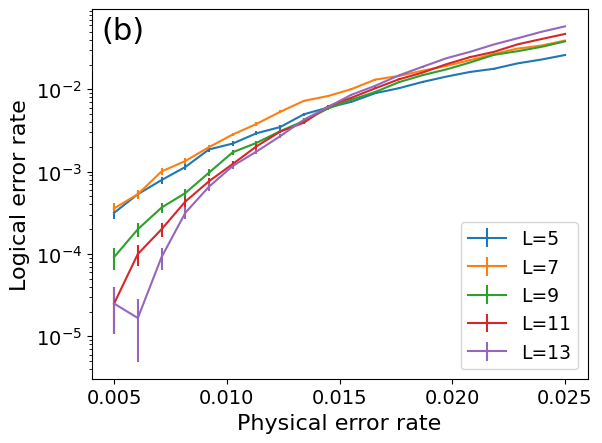

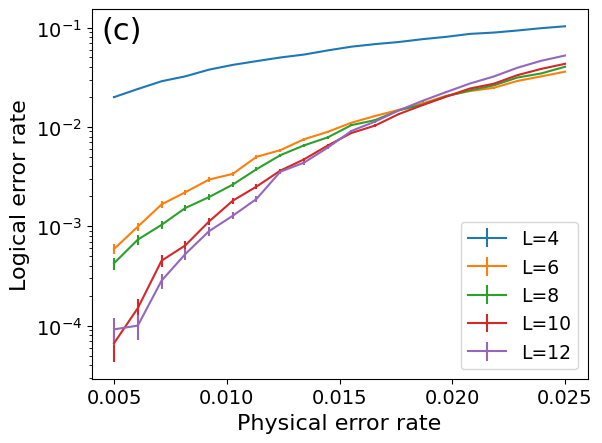

In [3]:
num_shots = 120000
df = pd.read_csv("pth_odd_even.csv")

ps = df["ps"].to_numpy()

plt.figure()
odd_cols = [c for c in df.columns if c.startswith("odd_L_")]
for c in odd_cols:
    logical_errors = df[c].to_numpy()
    L_str = c.replace("odd_L_", "")
    L = int(L_str)
    std_err = np.sqrt(logical_errors * (1 - logical_errors) / num_shots)
    plt.errorbar(ps, logical_errors, yerr=std_err, label=f"L={L}")

plt.yscale("log")
plt.xlabel("Physical error rate", fontsize=16)
plt.ylabel("Logical error rate",fontsize=16)
plt.legend(loc=0,fontsize=13.5);
plt.tick_params(labelsize=14)   
plt.text(0.02, 0.98, "(b)", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=22)
plt.savefig("pth_odd.pdf", format="pdf", bbox_inches="tight")

plt.figure()
even_cols = [c for c in df.columns if c.startswith("even_L_")]
for c in even_cols:
    logical_errors = df[c].to_numpy()
    L_str = c.replace("even_L_", "")
    L = int(L_str)
    std_err = np.sqrt(logical_errors * (1 - logical_errors) / num_shots)
    plt.errorbar(ps, logical_errors, yerr=std_err, label=f"L={L}")
plt.yscale("log")
plt.xlabel("Physical error rate", fontsize=16)
plt.ylabel("Logical error rate",fontsize=16)
plt.legend(loc=0,fontsize=13.5);
plt.tick_params(labelsize=14)
plt.text(0.02, 0.98, "(c)", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=22)
plt.savefig("pth_even.pdf", format="pdf", bbox_inches="tight")


ODD
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7108018447272965
             x: [ 1.356e-02  1.546e+00 -1.397e-03]
           nit: 33
          nfev: 65
 final_simplex: (array([[ 1.356e-02,  1.546e+00, -1.397e-03],
                       [ 1.360e-02,  1.548e+00, -1.425e-03],
                       [ 1.359e-02,  1.555e+00, -1.415e-03],
                       [ 1.360e-02,  1.556e+00, -1.433e-03]]), array([ 7.108e-01,  7.116e-01,  7.128e-01,  7.132e-01]))
         varco: [[ 1.237e-06 -1.745e-04 -7.102e-07]
                 [-1.745e-04  2.417e-01 -1.360e-04]
                 [-7.102e-07 -1.360e-04  9.874e-07]]
        errors: [ 1.112e-03  4.917e-01  9.937e-04]
           rho: 0.013562851671056307
            nu: 1.5461212429996758
          zeta: -0.0013970270851702213
          drho: 0.001112059512754864
           dnu: 0.49167991673385586
         dzeta: 0.0009936791997859757
EVEN
       message: Optimization terminated 

/Users/latoikka/anaconda3/envs/python3-11/lib/python3.11/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/Users/latoikka/anaconda3/envs/python3-11/lib/python3.11/site-packages/fssa/fssa.py:506: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(varco)), varco


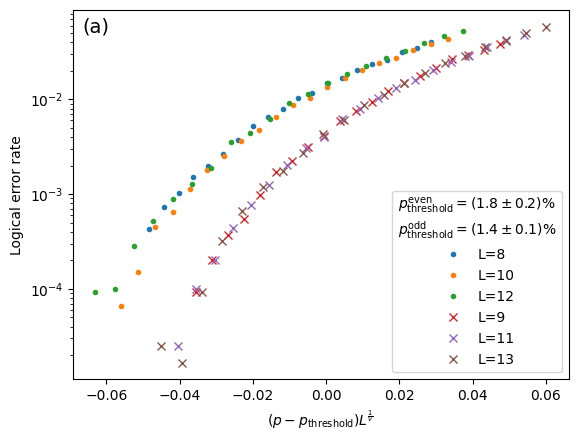

In [35]:
import fssa

num_shots = 120000
df = pd.read_csv("pth_odd_even.csv")
l_lo=2
lo, hi = 0, 15
odd_cols = [c for c in df.columns if c.startswith("odd_L_")]
even_cols = [c for c in df.columns if c.startswith("even_L_")]
odd_cols_sorted = sorted(odd_cols, key=lambda c: int(c.split("odd_L_")[1]))
even_cols_sorted = sorted(even_cols, key=lambda c: int(c.split("even_L_")[1]))
log_errors_all_L_odd  = df[odd_cols_sorted].to_numpy().T
log_errors_all_L_even = df[even_cols_sorted].to_numpy().T
L_odd = sorted((int(c.split("odd_L_")[1]) for c in odd_cols))
L_even = sorted((int(c.split("even_L_")[1]) for c in even_cols))
ps = df["ps"].to_numpy()

l=list(L_odd[l_lo:])
rho = list(ps)
a=np.array(log_errors_all_L_odd[l_lo:])
da=(a*(1-a)/num_shots)**0.5
rho_sub = rho[lo:hi]
a_sub = a[:, lo:hi]
da_sub = da[:, lo:hi]
mda = np.median(da[da > 0]) 
da[da == 0] = mda 
rho_c0 = 0.01
nu0 = 1.0
zeta0 = 0.0
res = fssa.autoscale(l, rho_sub, a_sub, da_sub, rho_c0, nu0, zeta0)
print("ODD")
print(res)
scaled_data_odd = fssa.scaledata(l, rho, a, da, res.rho, res.nu, res.zeta)

l=list(L_even[l_lo:])
rho = list(ps)
a=np.array(log_errors_all_L_even[l_lo:])
da=(a*(1-a)/num_shots)**0.5
mda = np.median(da[da > 0]) 
da[da == 0] = mda    
rho_sub = rho[lo:hi]
a_sub = a[:, lo:hi]
da_sub = da[:, lo:hi]
rho_c0 = 0.01
nu0 = 1.0
zeta0 = 0.0
res = fssa.autoscale(l, rho_sub, a_sub, da_sub, rho_c0, nu0, zeta0)
print("EVEN")
print(res)
scaled_data_even = fssa.scaledata(l, rho, a, da, res.rho, res.nu, res.zeta)
fig, ax = plt.subplots()
for itt, Ltt in enumerate(l):
    ax.plot(
        scaled_data_even.x.T[:, itt],
        scaled_data_even.y.T[:, itt],
        '.',
        label=f"L={Ltt}"
    )
for itt, Ltt in enumerate(list(L_odd[l_lo:])):
    ax.plot(
        scaled_data_odd.x.T[:, itt],
        scaled_data_odd.y.T[:, itt],
        'x',
        label=f"L={Ltt}"
    )   
ax.set_xlabel('$(p-p_\mathrm{threshold})L^\\frac{1}{\\nu}$')
ax.set_ylabel('Logical error rate')
ax.legend(title="$p_\mathrm{threshold}^\mathrm{even}=(1.8\pm 0.2)\\%$""\n""$p_\mathrm{threshold}^\mathrm{odd}=(1.4\pm 0.1)\\%$",loc=0)
plt.yscale("log")
ax.text(0.02, 0.98, "(a)", transform=ax.transAxes,
        ha="left", va="top", fontsize=14)
plt.show()
fig.savefig("pth.pdf", format="pdf", bbox_inches="tight")